# Project Completion Local + Vertex Notebook

This notebook keeps the working path small: data-processing SQL is imported from `project_completion/data_processing.py`, the trainer can run locally from the notebook, and the same package can be submitted as a Vertex AI Custom Job. CI/CD files are unchanged. Environment values are read from shell variables or `.env`.

## Environment Setup

Run this once in a fresh local or Workbench environment.

In [4]:
INSTALL_DEPS = False

if INSTALL_DEPS:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements-local.txt"])

# Required before Vertex submit or GCS package upload:
#   gcloud auth application-default login
#   gcloud auth login
#   gcloud config set project $PROJECT_ID

import os
from pathlib import Path

env_candidates = [Path(".env"), Path("env"), Path("env.txt"), Path(".env.txt")]
env_file = next((path for path in env_candidates if path.exists()), None)

if env_file:
    print("Loading environment from:", env_file)
    for line in env_file.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))
else:
    print("No env file found. Expected one of:", [str(path) for path in env_candidates])

required_env = ["PROJECT_ID", "REGION", "BUCKET"]
missing_env = [name for name in required_env if not os.getenv(name)]
if missing_env:
    print("Missing env vars:", missing_env)
    print("Upload env.example or export these variables before running Vertex/GCS cells.")
else:
    print("Environment ready:", {name: os.getenv(name) for name in required_env})


Loading environment from: env.txt
Environment ready: {'PROJECT_ID': 'qwiklabs-asl-03-7c1aaee9a503', 'REGION': 'us-central1', 'BUCKET': 'qwiklabs-asl-03-7c1aaee9a503'}


In [5]:
import glob
import math
import os
import subprocess
from datetime import datetime

from project_completion.data_processing import (
    DataProcessingConfig,
    build_export_jobs,
    build_feature_sql,
    build_preview_query,
    build_split_sql,
)

## Configuration

In [6]:
def get_gcloud_project(default="qwiklabs-asl-03-7c1aaee9a503"):
    try:
        value = subprocess.check_output(
            ["gcloud", "config", "get-value", "project"],
            stderr=subprocess.DEVNULL,
            text=True,
        ).strip()
        return value or default
    except Exception:
        return default


PROJECT_ID = os.getenv("PROJECT_ID", get_gcloud_project())
REGION = os.getenv("REGION", "us-central1")
BUCKET = os.getenv("BUCKET", PROJECT_ID)
BUCKET_URI = f"gs://{BUCKET}"

config = DataProcessingConfig(
    project_id=PROJECT_ID,
    dataset_id=os.getenv("DATASET_ID", "jindong_lin"),
    table_id=os.getenv("TABLE_ID", "project_data"),
    bucket_uri=os.getenv("DATA_GCS_BASE_URI", f"{BUCKET_URI}/jindong_lin/data"),
)

TRAIN_DATA_PATH = f"{config.data_gcs_prefix}/train/project-train-*"
EVAL_DATA_PATH = f"{config.data_gcs_prefix}/valid/project-valid-*"
SCHEMA_PATH = os.getenv("SCHEMA_PATH", getattr(config, "schema_gcs_path", f"{config.data_gcs_prefix}/schema/feature_schema.json"))
LOCAL_OUTPUT_DIR = f"{BUCKET_URI}/project_completion/local_embedding_dnn_test"

print("PROJECT_ID:", PROJECT_ID)
print("REGION:", REGION)
print("SOURCE_TABLE:", config.source_table)
print("TRAIN_DATA_PATH:", TRAIN_DATA_PATH)
print("EVAL_DATA_PATH:", EVAL_DATA_PATH)
print("SCHEMA_PATH:", SCHEMA_PATH)
print("LOCAL_OUTPUT_DIR:", LOCAL_OUTPUT_DIR)


PROJECT_ID: qwiklabs-asl-03-7c1aaee9a503
REGION: us-central1
SOURCE_TABLE: qwiklabs-asl-03-7c1aaee9a503.jindong_lin.project_completion_dataform_features_mask_0615
TRAIN_DATA_PATH: gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/train/project-train-*
EVAL_DATA_PATH: gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/valid/project-valid-*
SCHEMA_PATH: gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/schema/feature_schema.json
LOCAL_OUTPUT_DIR: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/local_embedding_dnn_test


## Data Processing Smoke Test

In [7]:
preview_query = build_preview_query(config.source_table)
feature_sql = build_feature_sql(config.source_table, config.feature_table)
split_sql = build_split_sql(config.feature_table, config.train_table, config.valid_table, config.test_table)
export_jobs = build_export_jobs(config)

assert f"FROM `{config.source_table}`" in preview_query
assert "SELECT *" in feature_sql
assert "days_to_S90 IS NOT NULL" in feature_sql
assert "days_to_S90 >= 0" in feature_sql
#assert "so_nr" in split_sql
#assert "projekt_id" in split_sql
#assert "FARM_FINGERPRINT" in split_sql
assert export_jobs[0][1].endswith("/train/project-train-*.csv")
assert export_jobs[1][1].endswith("/valid/project-valid-*.csv")
assert config.schema_gcs_path.endswith("/schema/feature_schema.json")

print("Data-processing helper smoke test passed.")


Data-processing helper smoke test passed.


## Optional Data Processing

Keep `RUN_DATA_PROCESSING = False` for normal training runs. Set it to `True` only for the first run or when the source BigQuery table has changed and the GCS CSV files must be regenerated.

In [8]:
RUN_DATA_PROCESSING = os.getenv("RUN_DATA_PROCESSING", "False").lower() == "true"

if RUN_DATA_PROCESSING:
    from google.cloud import bigquery, storage
    from project_completion.data_processing import export_tables_to_gcs, run_bigquery_data_processing

    bq_client = bigquery.Client(project=PROJECT_ID)
    storage_client = storage.Client(project=PROJECT_ID)
    bq_location = os.getenv("BQ_LOCATION")
    if not bq_location:
        dataset_ref = bigquery.DatasetReference(PROJECT_ID, config.dataset_id)
        bq_location = bq_client.get_dataset(dataset_ref).location

    row_counts = run_bigquery_data_processing(bq_client, config, location=bq_location)
    export_tables_to_gcs(
        bq_client,
        config,
        location=bq_location,
        storage_client=storage_client,
        clean_existing=True,
    )
    print("Regenerated CSV files from BigQuery.")
    print(row_counts)
else:
    print("Skip data processing. Reusing existing CSV files in GCS:")
    print("  train:", TRAIN_DATA_PATH)
    print("  valid:", EVAL_DATA_PATH)


Regenerated CSV files from BigQuery.
{'qwiklabs-asl-03-7c1aaee9a503.jindong_lin.project_completion_features': 53568, 'qwiklabs-asl-03-7c1aaee9a503.jindong_lin.project_completion_train': 41552, 'qwiklabs-asl-03-7c1aaee9a503.jindong_lin.project_completion_valid': 8397, 'qwiklabs-asl-03-7c1aaee9a503.jindong_lin.project_completion_test': 3619}


In [9]:
os.getenv("LOCAL_EPOCHS")

'20'

## Run the trainer locally from the notebook

In [11]:
def _env_int(name, default):
    return int(os.getenv(name, str(default)))


def _env_float(name, default):
    return float(os.getenv(name, str(default)))


def _resolve_steps(env_name, table_name, batch_size, fallback, max_steps=None):
    raw_value = os.getenv(env_name, "AUTO")
    if raw_value.upper() != "AUTO":
        return int(raw_value)

    try:
        from google.cloud import bigquery
        bq_client_for_counts = bigquery.Client(project=PROJECT_ID)
        rows = bq_client_for_counts.get_table(table_name).num_rows
        if rows == 0:
            raise ValueError(f"{table_name} has 0 rows")
        steps = max(1, math.ceil(rows / batch_size))
        if max_steps is not None:
            steps = min(max_steps, steps)
        print(f"{env_name}=AUTO -> {steps} steps from {rows} rows in {table_name}")
        return steps
    except Exception as exc:
        print(f"{env_name}=AUTO could not read BigQuery row count: {exc}")
        print(f"Falling back to {fallback}. Set {env_name} explicitly in .env to override.")
        return fallback


LOCAL_BATCH_SIZE = _env_int("LOCAL_BATCH_SIZE", 64)
LOCAL_EPOCHS = _env_int("LOCAL_EPOCHS", 10)
LOCAL_TRAIN_STEPS_PER_EPOCH = _resolve_steps(
    "LOCAL_TRAIN_STEPS_PER_EPOCH",
    config.train_table,
    LOCAL_BATCH_SIZE,
    fallback=1,
    max_steps=_env_int("LOCAL_MAX_TRAIN_STEPS_PER_EPOCH", 100),
)
LOCAL_VALIDATION_STEPS = _resolve_steps(
    "LOCAL_VALIDATION_STEPS",
    config.valid_table,
    LOCAL_BATCH_SIZE,
    fallback=1,
    max_steps=_env_int("LOCAL_MAX_VALIDATION_STEPS", 50),
)
HIDDEN_UNITS = os.getenv("HIDDEN_UNITS", "128 64 32")
LEARNING_RATE = _env_float("LEARNING_RATE", 0.001)
DROPOUT_RATE = _env_float("DROPOUT_RATE", 0.2)
LABEL_SCALE = _env_float("LABEL_SCALE", 365.0)

print("Local batch size:", LOCAL_BATCH_SIZE)
print("Local epochs:", LOCAL_EPOCHS)
print("Local train_steps_per_epoch:", LOCAL_TRAIN_STEPS_PER_EPOCH)
print("Local validation_steps:", LOCAL_VALIDATION_STEPS)
print("Schema path:", SCHEMA_PATH)

local_train_cmd = [
    "python", "-m", "trainer.task",
    "--train_data_path", TRAIN_DATA_PATH,
    "--eval_data_path", EVAL_DATA_PATH,
    "--schema_path", SCHEMA_PATH,
    "--output_dir", LOCAL_OUTPUT_DIR,
    "--batch_size", str(LOCAL_BATCH_SIZE),
    "--epochs", str(LOCAL_EPOCHS),
    "--train_steps_per_epoch", str(LOCAL_TRAIN_STEPS_PER_EPOCH),
    "--validation_steps", str(LOCAL_VALIDATION_STEPS),
    "--hidden_units", HIDDEN_UNITS,
    "--learning_rate", str(LEARNING_RATE),
    "--dropout_rate", str(DROPOUT_RATE),
    "--label_scale", str(LABEL_SCALE),
]

env = os.environ.copy()
env.setdefault("CUDA_VISIBLE_DEVICES", "-1")
env.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

subprocess.run(local_train_cmd, cwd="project_completion", env=env, check=True)


Local batch size: 64
Local epochs: 20
Local train_steps_per_epoch: 649
Local validation_steps: 64
Schema path: gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/schema/feature_schema.json


2026-06-16 07:56:25.820929: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-16 07:56:25.850838: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-16 07:56:25.859840: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Feature schema: {
  "categorical_features": [
    "zustaendige_region",
    "ziel_des_projekts",
    "area_gu",
    "dim_squads_mac"
  ],
  "csv_columns": [
    "so_nr",
    "projekt_id",
    "zustaendige_region",
    "ziel_des_projekts",
    "area_gu",
    "dim_squads_mac",
    "days_to_S90",
    "data_split",
    "missing_stx44",
    "days_stx44_from_stx30",
    "missing_stx51a",
    "days_stx51a_from_stx30",
    "missing_stx52",
    "days_stx52_from_stx30",
    "missing_stx56a",
    "days_stx56a_from_stx30",
    "missing_stx68",
    "days_stx68_from_stx30",
    "missing_stx71",
    "days_stx71_from_stx30"
  ],
  "excluded_columns": [
    "data_split"
  ],
  "field_types": {
    "area_gu": "STRING",
    "data_split": "STRING",
    "days_stx44_from_stx30": "INTEGER",
    "days_stx51a_from_stx30": "INTEGER",
    "days_stx52_from_stx30": "INTEGER",
    "days_stx56a_from_stx30": "INTEGER",
    "days_stx68_from_stx30": "INTEGER",
    "days_stx71_from_stx30": "INTEGER",
    "days_to_S90": 

CompletedProcess(args=['python', '-m', 'trainer.task', '--train_data_path', 'gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/train/project-train-*', '--eval_data_path', 'gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/valid/project-valid-*', '--schema_path', 'gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/schema/feature_schema.json', '--output_dir', 'gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/local_embedding_dnn_test', '--batch_size', '64', '--epochs', '20', '--train_steps_per_epoch', '649', '--validation_steps', '64', '--hidden_units', '128 64 32', '--learning_rate', '0.001', '--dropout_rate', '0.2', '--label_scale', '365.0'], returncode=0)

## View Local Training with TensorBoard

Run this cell after local training finishes to inspect TensorBoard logs written under `LOCAL_OUTPUT_DIR/tensorboard`.


In [12]:
# TensorBoard for the local trainer output.
# If the extension is already loaded, Jupyter may print a harmless message.
#!kill 28504
%load_ext tensorboard

TENSORBOARD_LOGDIR = f"{LOCAL_OUTPUT_DIR.rstrip('/')}/tensorboard"
print("TensorBoard logdir:", TENSORBOARD_LOGDIR)
%tensorboard --logdir {TENSORBOARD_LOGDIR} --port 8000


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
TensorBoard logdir: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/local_embedding_dnn_test/tensorboard


## Submit Custom Job using the Vertex AI SDK

This section creates or reuses a Vertex AI TensorBoard instance by default, gets the compute service account with `gcloud`, and submits the Custom Job with both `service_account` and `tensorboard`.


In [13]:
os.getenv("VERTEX_EPOCHS")

'30'

In [14]:
from google.cloud import aiplatform

RUN_VERTEX_CUSTOM_JOB = os.getenv("RUN_VERTEX_CUSTOM_JOB", "True").lower() == "true"

# Get the compute service account from the current GCP project.
GCP_SRV_ACC = !gcloud iam service-accounts list --filter="email ~ -compute@developer.gserviceaccount.com" --format="value(email)"
if not GCP_SRV_ACC:
    raise ValueError("No compute service account found. Check gcloud project/account configuration.")
GCP_SERV_ACCOUNT = GCP_SRV_ACC[0]
print("GCP_SERV_ACCOUNT:", GCP_SERV_ACCOUNT)

# Create or reuse a Vertex AI TensorBoard instance.
aiplatform.init(project=PROJECT_ID, location=REGION, staging_bucket=f"{BUCKET_URI}/project_completion/staging")

TB_DISPLAY_NAME = "project-forecast-tensorboard"

existing_tensorboards = aiplatform.Tensorboard.list(
    filter=f"display_name={TB_DISPLAY_NAME}",
    project=PROJECT_ID,
    location=REGION,
)

if existing_tensorboards:
    print(f"Found existing TensorBoard instance: {TB_DISPLAY_NAME}")
    tensorboard = existing_tensorboards[0]
else:
    print(f"TensorBoard instance '{TB_DISPLAY_NAME}' not found. Creating a new one...")
    tensorboard = aiplatform.Tensorboard.create(
        display_name=TB_DISPLAY_NAME,
        project=PROJECT_ID,
        location=REGION,
    )

TB_RESOURCE_NAME = tensorboard.resource_name
print(f"TB_RESOURCE_NAME: {TB_RESOURCE_NAME}")

VERTEX_BATCH_SIZE = _env_int("VERTEX_BATCH_SIZE", 64)
VERTEX_EPOCHS = _env_int("VERTEX_EPOCHS", 10)
VERTEX_TRAIN_STEPS_PER_EPOCH = _resolve_steps(
    "VERTEX_TRAIN_STEPS_PER_EPOCH",
    config.train_table,
    VERTEX_BATCH_SIZE,
    fallback=1,
    max_steps=None,
)
VERTEX_VALIDATION_STEPS = _resolve_steps(
    "VERTEX_VALIDATION_STEPS",
    config.valid_table,
    VERTEX_BATCH_SIZE,
    fallback=1,
    max_steps=None,
)

print("Vertex batch size:", VERTEX_BATCH_SIZE)
print("Vertex epochs:", VERTEX_EPOCHS)
print("Vertex train_steps_per_epoch:", VERTEX_TRAIN_STEPS_PER_EPOCH)
print("Vertex validation_steps:", VERTEX_VALIDATION_STEPS)
print("Schema path:", SCHEMA_PATH)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
MODEL_OUTPUT_DIR = f"{BUCKET_URI}/project_completion/trained_dnn_model_{timestamp}"
PACKAGE_URI = os.getenv("PACKAGE_URI") or f"{BUCKET_URI}/project_completion/packages/project_completion_trainer_{timestamp}.tar.gz"
TRAINING_IMAGE_URI = os.getenv(
    "TRAINING_IMAGE_URI",
    "us-docker.pkg.dev/vertex-ai/training/tf-cpu.2-17.py310:latest",
)

subprocess.run(["python", "setup.py", "sdist", "--formats=gztar"], cwd="project_completion", check=True)
local_package = sorted(glob.glob("project_completion/dist/*.tar.gz"))[-1]
subprocess.run(["gcloud", "storage", "cp", local_package, PACKAGE_URI], check=True)

worker_pool_specs = [
    {
        "machine_spec": {"machine_type": os.getenv("VERTEX_MACHINE_TYPE", "n1-standard-4")},
        "replica_count": 1,
        "python_package_spec": {
            "executor_image_uri": TRAINING_IMAGE_URI,
            "package_uris": [PACKAGE_URI],
            "python_module": "trainer.task",
            "args": [
                "--train_data_path", TRAIN_DATA_PATH,
                "--eval_data_path", EVAL_DATA_PATH,
                "--schema_path", SCHEMA_PATH,
                "--output_dir", MODEL_OUTPUT_DIR,
                "--batch_size", str(VERTEX_BATCH_SIZE),
                "--epochs", str(VERTEX_EPOCHS),
                "--train_steps_per_epoch", str(VERTEX_TRAIN_STEPS_PER_EPOCH),
                "--validation_steps", str(VERTEX_VALIDATION_STEPS),
                "--hidden_units", HIDDEN_UNITS,
                "--learning_rate", str(LEARNING_RATE),
                "--dropout_rate", str(DROPOUT_RATE),
                "--label_scale", str(LABEL_SCALE),
            ],
        },
    }
]

job = aiplatform.CustomJob(
    display_name=f"project_completion_dnn_training_{timestamp}",
    worker_pool_specs=worker_pool_specs,
    base_output_dir=MODEL_OUTPUT_DIR,
)

if RUN_VERTEX_CUSTOM_JOB:
    job.submit(
        service_account=GCP_SERV_ACCOUNT,
        tensorboard=TB_RESOURCE_NAME,
    )
    print("Submitted Custom Job:", job.resource_name)
    print("MODEL_OUTPUT_DIR:", MODEL_OUTPUT_DIR)
    print("Vertex AI TensorBoard:", TB_RESOURCE_NAME)
else:
    print("Custom Job is configured but not submitted. Set RUN_VERTEX_CUSTOM_JOB=True to submit.")
    print("PACKAGE_URI:", PACKAGE_URI)
    print("MODEL_OUTPUT_DIR:", MODEL_OUTPUT_DIR)
    print("Vertex AI TensorBoard:", TB_RESOURCE_NAME)


/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/google/cloud/aiplatform/models.py:52: FutureWarning: Support for google-cloud-storage < 3.0.0 will be removed in a future version of google-cloud-aiplatform. Please upgrade to google-cloud-storage >= 3.0.0.
  from google.cloud.aiplatform.utils import gcs_utils


GCP_SERV_ACCOUNT: 192763454488-compute@developer.gserviceaccount.com
Found existing TensorBoard instance: project-forecast-tensorboard
TB_RESOURCE_NAME: projects/192763454488/locations/us-central1/tensorboards/6279198756042702848
VERTEX_TRAIN_STEPS_PER_EPOCH=AUTO -> 650 steps from 41552 rows in qwiklabs-asl-03-7c1aaee9a503.jindong_lin.project_completion_train
VERTEX_VALIDATION_STEPS=AUTO -> 132 steps from 8397 rows in qwiklabs-asl-03-7c1aaee9a503.jindong_lin.project_completion_valid
Vertex batch size: 64
Vertex epochs: 30
Vertex train_steps_per_epoch: 650
Vertex validation_steps: 132
Schema path: gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/schema/feature_schema.json
running sdist
running egg_info
writing project_completion_trainer.egg-info/PKG-INFO
writing dependency_links to project_completion_trainer.egg-info/dependency_links.txt
writing requirements to project_completion_trainer.egg-info/requires.txt
writing top-level names to project_completion_trainer.egg

removing 'project_completion_trainer-0.1' (and everything under it)


Copying file://project_completion/dist/project_completion_trainer-0.1.tar.gz to gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/packages/project_completion_trainer_20260616_075911.tar.gz
  



Creating CustomJob
CustomJob created. Resource name: projects/192763454488/locations/us-central1/customJobs/8366385169195597824
To use this CustomJob in another session:
custom_job = aiplatform.CustomJob.get('projects/192763454488/locations/us-central1/customJobs/8366385169195597824')
View Custom Job:
https://console.cloud.google.com/agent-platform/locations/us-central1/training/8366385169195597824?project=192763454488
View Tensorboard:
https://us-central1.tensorboard.googleusercontent.com/experiment/projects+192763454488+locations+us-central1+tensorboards+6279198756042702848+experiments+8366385169195597824
Submitted Custom Job: projects/192763454488/locations/us-central1/customJobs/8366385169195597824
MODEL_OUTPUT_DIR: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/trained_dnn_model_20260616_075911
Vertex AI TensorBoard: projects/192763454488/locations/us-central1/tensorboards/6279198756042702848


In [45]:
VERTEX_MODEL_DIR = "gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/trained_dnn_model_20260616_075911"
ACTIVE_MODEL_PATH = f"{VERTEX_MODEL_DIR.rstrip('/')}/model.keras"

print("Using Vertex model:", ACTIVE_MODEL_PATH)


Using Vertex model: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/trained_dnn_model_20260615_120709/model.keras


In [46]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from project_completion.trainer import model as trainer_model

# 1. Load schema and trained local model
schema = trainer_model.load_feature_schema(SCHEMA_PATH)
#model_path = f"{LOCAL_OUTPUT_DIR.rstrip('/')}/model.keras"
print("Loading model from:", model_path)
#trained_model = keras.models.load_model(model_path)

trained_model = keras.models.load_model(ACTIVE_MODEL_PATH)


# 2. Use TEST data for final evaluation
TEST_DATA_PATH = "gs://qwiklabs-asl-03-7c1aaee9a503/jindong_lin/data/project_completion/test/project-test-*"

pred_ds = trainer_model.create_dataset(
    TEST_DATA_PATH,
    batch_size=LOCAL_BATCH_SIZE,
    schema=schema,
    num_repeat=1,
    mode="eval",
    label_scale=LABEL_SCALE,
)

# 3. Collect actual / predicted values in original day units
rows = []
for features, scaled_label in pred_ds:
    scaled_pred = trained_model.predict(features, verbose=0)
    y_true = tf.reshape(scaled_label, [-1]).numpy() * LABEL_SCALE
    y_pred = tf.reshape(scaled_pred, [-1]).numpy() * LABEL_SCALE
    rows.append(pd.DataFrame({
        "actual_days_to_S90": y_true,
        "predicted_days_to_S90": y_pred,
        "error_days": y_pred - y_true,
    }))

pred_df = pd.concat(rows, ignore_index=True)

mae = np.mean(np.abs(pred_df["error_days"]))
rmse = np.sqrt(np.mean(np.square(pred_df["error_days"])))

print(f"Rows: {len(pred_df):,}")
print(f"MAE days: {mae:.2f}")
print(f"RMSE days: {rmse:.2f}")

pred_df.head()


Loading model from: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/local_embedding_dnn_test/model.keras
Rows: 3,619
MAE days: 53.20
RMSE days: 97.07


,actual_days_to_S90,predicted_days_to_S90,error_days
0,58.0,96.250267,38.250267
1,104.0,109.241295,5.241295
2,45.0,85.934151,40.934151
3,90.0,91.915810,1.915810
4,49.0,90.862213,41.862213


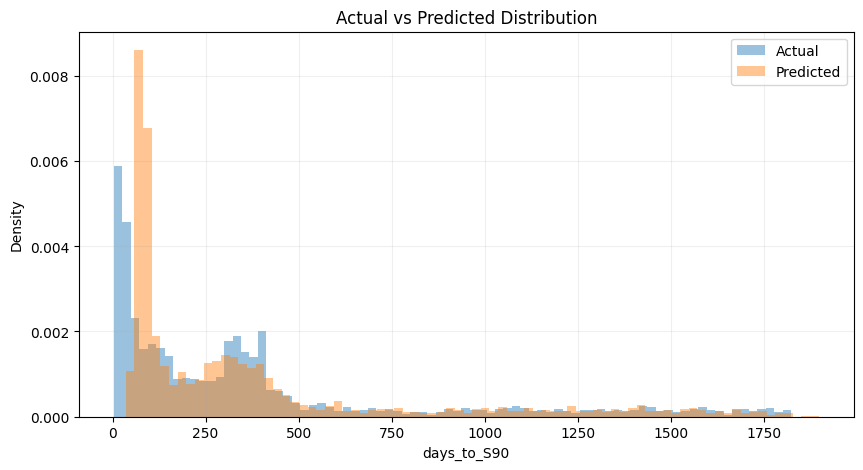

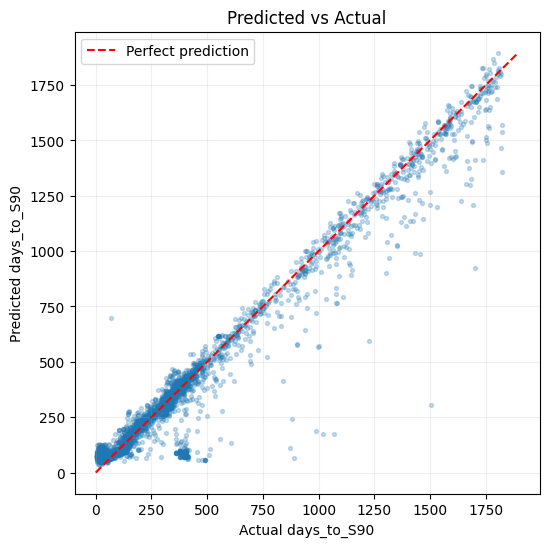

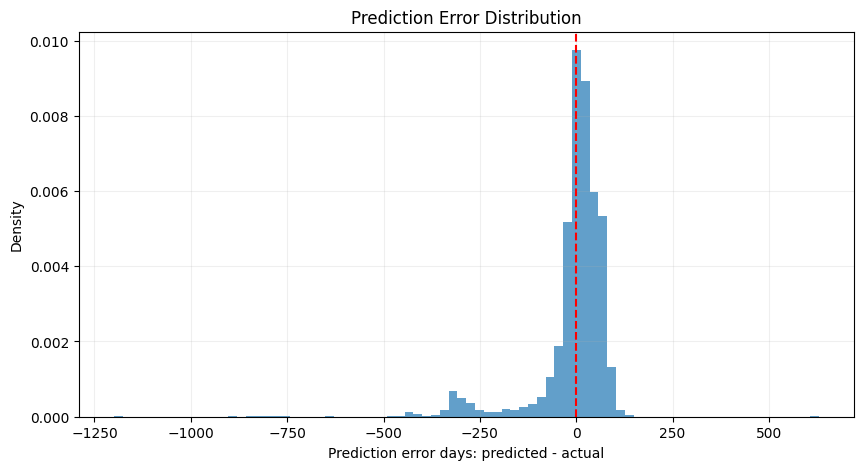

In [47]:
# 1. Actual vs predicted distribution
plt.figure(figsize=(10, 5))
plt.hist(pred_df["actual_days_to_S90"], bins=80, density=True, alpha=0.45, label="Actual")
plt.hist(pred_df["predicted_days_to_S90"], bins=80, density=True, alpha=0.45, label="Predicted")
plt.xlabel("days_to_S90")
plt.ylabel("Density")
plt.title("Actual vs Predicted Distribution")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# 2. Predicted vs actual scatter
plt.figure(figsize=(6, 6))
plt.scatter(pred_df["actual_days_to_S90"], pred_df["predicted_days_to_S90"], alpha=0.25, s=8)
max_v = max(pred_df["actual_days_to_S90"].max(), pred_df["predicted_days_to_S90"].max())
plt.plot([0, max_v], [0, max_v], "r--", label="Perfect prediction")
plt.xlabel("Actual days_to_S90")
plt.ylabel("Predicted days_to_S90")
plt.title("Predicted vs Actual")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# 3. Error distribution
plt.figure(figsize=(10, 5))
plt.hist(pred_df["error_days"], bins=80, density=True, alpha=0.7)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Prediction error days: predicted - actual")
plt.ylabel("Density")
plt.title("Prediction Error Distribution")
plt.grid(alpha=0.2)
plt.show()


In [33]:
predictions_path = f"{LOCAL_OUTPUT_DIR.rstrip('/')}/predictions/test_predictions.csv"
tf.io.gfile.makedirs(f"{LOCAL_OUTPUT_DIR.rstrip('/')}/predictions")

with tf.io.gfile.GFile(predictions_path, "w") as f:
    pred_df.to_csv(f, index=False)

print("Saved predictions to:", predictions_path)


Saved predictions to: gs://qwiklabs-asl-03-7c1aaee9a503/project_completion/local_embedding_dnn_test/predictions/test_predictions.csv


In [48]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import tensorflow as tf
import keras

from project_completion.trainer import model as trainer_model

schema = trainer_model.load_feature_schema(SCHEMA_PATH)
#model_path = f"{LOCAL_OUTPUT_DIR.rstrip('/')}/model.keras"
#trained_model = keras.models.load_model(model_path)
trained_model = keras.models.load_model(ACTIVE_MODEL_PATH)

bq_client = bigquery.Client(project=PROJECT_ID)

SCORING_TABLE = "qwiklabs-asl-03-7c1aaee9a503.jindong_lin.frozenlist-2026-forecast"

input_columns = schema["categorical_features"] + schema["numeric_features"]
meta_columns = [
    "so_nr",
    "projekt_id",
    "ist_stx30",
    "ist_stx90",
]

select_columns = meta_columns + input_columns
select_sql = ",".join([f"`{c}`" for c in select_columns])

score_sql = f"""
SELECT
  {select_sql}
FROM `{SCORING_TABLE}`
WHERE ist_stx30 IS NOT NULL
"""

score_df = bq_client.query(score_sql).to_dataframe()
print("Rows to predict:", len(score_df))
score_df.head()


/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Rows to predict: 8349


,so_nr,projekt_id,ist_stx30,ist_stx90,zustaendige_region,ziel_des_projekts,area_gu,dim_squads_mac,missing_stx44,days_stx44_from_stx30,missing_stx51a,days_stx51a_from_stx30,missing_stx52,days_stx52_from_stx30,missing_stx56a,days_stx56a_from_stx30,missing_stx68,days_stx68_from_stx30,missing_stx71,days_stx71_from_stx30
0,124992506,700961697,2021-02-11,NaT,R1,Z19,A7,S1,0,90,0,1764,0,1386,0,1701,1,-1,1,-1
1,125991509,700961617,2021-02-11,NaT,R1,Z19,A7,S1,0,273,0,1885,0,264,0,1645,1,-1,1,-1
2,128990077,700965639,2021-03-16,NaT,R1,Z18,A7,S1,0,10,1,-1,0,352,1,-1,1,-1,1,-1
3,127990162,700965295,2021-05-06,2026-03-19,R1,Z18,A7,S1,0,19,0,1596,0,439,0,1398,1,-1,0,1814
4,128990437,700965776,2021-05-06,NaT,R1,Z18,A7,S1,0,209,1,-1,0,168,1,-1,1,-1,1,-1


In [49]:
model_inputs = {}

for col in schema["categorical_features"]:
    model_inputs[col] = tf.constant(
        score_df[col]
        .fillna("UNKNOWN")
        .astype(str)
        .to_numpy()
        .reshape(-1, 1),
        dtype=tf.string,
    )

for col in schema["numeric_features"]:
    model_inputs[col] = tf.constant(
        pd.to_numeric(score_df[col], errors="coerce")
        .fillna(0.0)
        .astype("float32")
        .to_numpy()
        .reshape(-1, 1),
        dtype=tf.float32,
    )

scaled_pred = trained_model.predict(
    model_inputs,
    batch_size=LOCAL_BATCH_SIZE,
    verbose=1,
)

predicted_days = scaled_pred.reshape(-1) * LABEL_SCALE

prediction_df = score_df[meta_columns].copy()
prediction_df["predicted_days_to_S90"] = predicted_days
prediction_df["predicted_months_to_S90"] = prediction_df["predicted_days_to_S90"] / 30.4375
prediction_df["predicted_quarters_to_S90"] = prediction_df["predicted_days_to_S90"] / 91.3125

prediction_df["ist_stx30"] = pd.to_datetime(prediction_df["ist_stx30"])
prediction_df["ist_stx90"] = pd.to_datetime(prediction_df["ist_stx90"])

prediction_df["predicted_s90_date"] = prediction_df["ist_stx30"] + pd.to_timedelta(
    prediction_df["predicted_days_to_S90"].round().astype(int),
    unit="D",
)

prediction_df["predicted_s90_month"] = prediction_df["predicted_s90_date"].dt.to_period("M").astype(str)
prediction_df["predicted_s90_quarter"] = prediction_df["predicted_s90_date"].dt.to_period("Q").astype(str)

prediction_df["actual_s90_month"] = prediction_df["ist_stx90"].dt.to_period("M").astype(str)
prediction_df["actual_s90_quarter"] = prediction_df["ist_stx90"].dt.to_period("Q").astype(str)

prediction_df.head(20)


131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,so_nr,projekt_id,ist_stx30,ist_stx90,predicted_days_to_S90,predicted_months_to_S90,predicted_quarters_to_S90,predicted_s90_date,predicted_s90_month,predicted_s90_quarter,actual_s90_month,actual_s90_quarter
0,124992506,700961697,2021-02-11,NaT,1504.600952,49.432476,16.477491,2025-03-27,2025-03,2025Q1,NaN,NaN
1,125991509,700961617,2021-02-11,NaT,1694.584229,55.674225,18.558075,2025-10-03,2025-10,2025Q4,NaN,NaN
2,128990077,700965639,2021-03-16,NaT,693.405151,22.781279,7.593760,2023-02-07,2023-02,2023Q1,NaN,NaN
3,127990162,700965295,2021-05-06,2026-03-19,1711.620117,56.233925,18.744642,2026-01-12,2026-01,2026Q1,2026-03,2026Q1
4,128990437,700965776,2021-05-06,NaT,686.809509,22.564583,7.521528,2023-03-24,2023-03,2023Q1,NaN,NaN
5,128990240,700965657,2021-05-11,NaT,694.439941,22.815275,7.605092,2023-04-05,2023-04,2023Q2,NaN,NaN
6,124992218,700961176,2021-06-08,2026-06-05,1607.116943,52.800556,17.600185,2025-11-01,2025-11,2025Q4,2026-06,2026Q2
7,128992387,700965734,2021-06-11,NaT,687.224976,22.578234,7.526078,2023-04-29,2023-04,2023Q2,NaN,NaN
8,127991823,701088207,2021-06-14,NaT,1464.104370,48.101990,16.033997,2025-06-17,2025-06,2025Q2,NaN,NaN
9,125991589,701097348,2021-07-06,NaT,684.393982,22.485224,7.495074,2023-05-21,2023-05,2023Q2,NaN,NaN


In [50]:
completed_df = prediction_df[prediction_df["ist_stx90"].notna()].copy()

completed_df["actual_days_to_S90"] = (
    completed_df["ist_stx90"] - completed_df["ist_stx30"]
).dt.days

completed_df["error_days"] = completed_df["predicted_days_to_S90"] - completed_df["actual_days_to_S90"]

completed_summary = pd.DataFrame({
    "metric": ["mae_days", "rmse_days", "bias_days"],
    "value": [
        np.mean(np.abs(completed_df["error_days"])),
        np.sqrt(np.mean(np.square(completed_df["error_days"]))),
        np.mean(completed_df["error_days"]),
    ],
})

completed_summary

,metric,value
0,mae_days,76.806428
1,rmse_days,131.407713
2,bias_days,23.515185


In [51]:
OUTPUT_TABLE = "qwiklabs-asl-03-7c1aaee9a503.jindong_lin.frozenlist_2026_forecast_predictions"

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
)

load_job = bq_client.load_table_from_dataframe(
    prediction_df,
    OUTPUT_TABLE,
    job_config=job_config,
)
load_job.result()

/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/google/cloud/bigquery/_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


LoadJob<project=qwiklabs-asl-03-7c1aaee9a503, location=us-central1, id=a7490356-0836-4ec5-8be4-afd9cac7a7cf>

In [52]:
print("Saved BigQuery table:", OUTPUT_TABLE)


Saved BigQuery table: qwiklabs-asl-03-7c1aaee9a503.jindong_lin.frozenlist_2026_forecast_predictions


In [53]:
compare_sql = """
WITH test_keys AS (
  SELECT
    CAST(so_nr AS STRING) AS so_nr,
    CAST(projekt_id AS STRING) AS projekt_id,
    days_to_S90
  FROM `qwiklabs-asl-03-7c1aaee9a503.jindong_lin.project_completion_test`
),
score_completed AS (
  SELECT
    CAST(so_nr AS STRING) AS so_nr,
    CAST(projekt_id AS STRING) AS projekt_id,
    DATE_DIFF(DATE(ist_stx90), DATE(ist_stx30), DAY) AS actual_days_to_S90
  FROM `qwiklabs-asl-03-7c1aaee9a503.jindong_lin.frozenlist-2026-forecast`
  WHERE ist_stx30 IS NOT NULL
    AND ist_stx90 IS NOT NULL
)
SELECT
  COUNT(*) AS joined_rows,
  COUNTIF(t.so_nr IS NULL) AS only_in_score_completed,
  COUNTIF(s.so_nr IS NULL) AS only_in_test,
  AVG(ABS(t.days_to_S90 - s.actual_days_to_S90)) AS avg_label_diff
FROM test_keys t
FULL OUTER JOIN score_completed s
USING (so_nr, projekt_id)
"""

bq_client.query(compare_sql).to_dataframe()


/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,joined_rows,only_in_score_completed,only_in_test,avg_label_diff
0,3687,68,878,0.0
